<a href="https://colab.research.google.com/github/BenRyan-8/MarketingAnalytics_CA/blob/main/marketinganalyticsCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/BenRyan-8/MarketingAnalytics_CA/main/Walmart.csv"
df_walmart = pd.read_csv(url)
df_walmart.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [2]:
df_walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [3]:
df_walmart.shape

(6435, 8)

In [4]:
df_walmart.duplicated().sum()

np.int64(0)

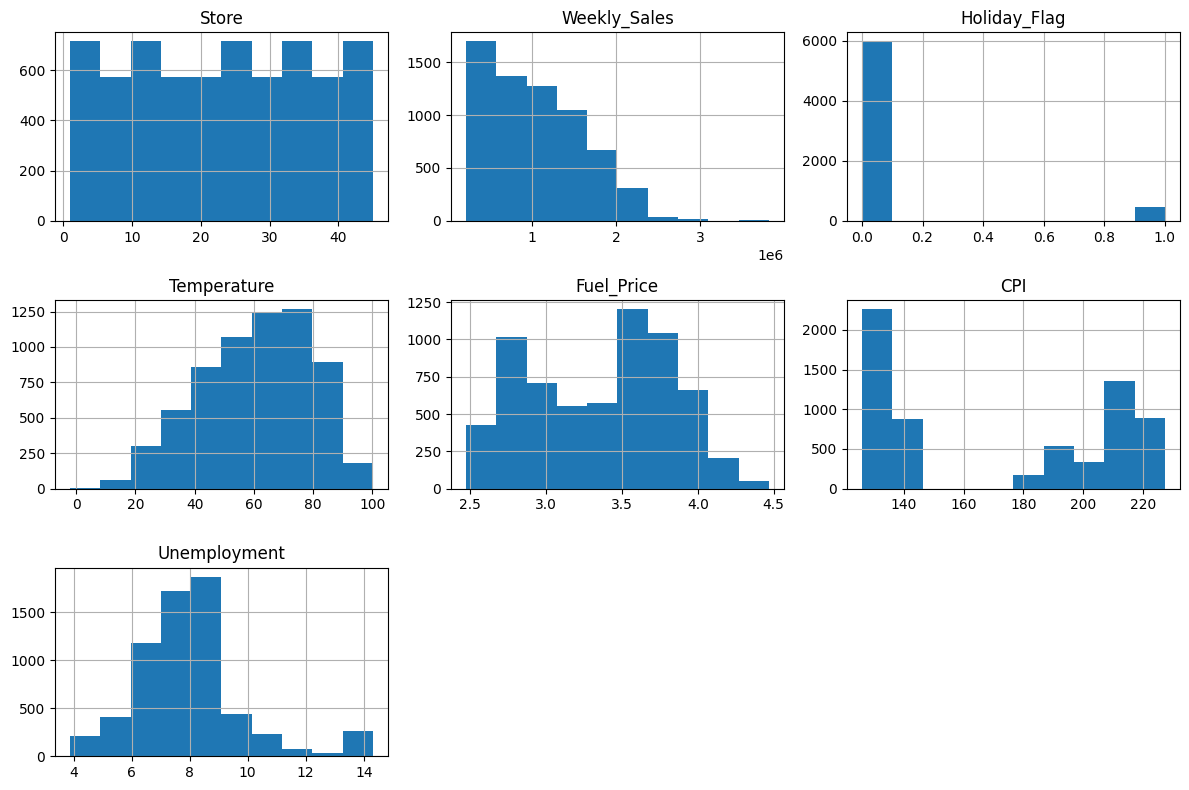

In [5]:
import matplotlib.pyplot as plt

df_walmart.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [6]:
df_walmart['Date'] = pd.to_datetime(df_walmart['Date'],dayfirst=True)
df_walmart = df_walmart.sort_values(by = 'Date', ascending= True)

In [7]:
df_eda = df_walmart.copy()
df_tree = df_walmart.copy()
df_scaled = df_walmart.copy()

In [8]:
#df_eda['Date'] = pd.to_datetime(df_eda['Date'],dayfirst=True)

df_eda['Year'] = df_eda['Date'].dt.year
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Week'] = df_eda['Date'].dt.isocalendar().week

In [9]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 534.2 KB


#pre-processing RF, XG, LightGBM, ADAboost - just log tranformation

Log transformation to deal with skew

In [10]:
df_tree['Weekly_Sales'] = np.log1p(df_tree['Weekly_Sales'])

In [11]:
df_tree['Date'] = pd.to_datetime(df_tree['Date'],dayfirst=True)

df_tree['Year'] = df_tree['Date'].dt.year
df_tree['Month'] = df_tree['Date'].dt.month
df_tree['Week'] = df_tree['Date'].dt.isocalendar().week

In [12]:
df_tree['Month_sin'] = np.sin(2 * np.pi * df_tree['Month'] / 12)
df_tree['Month_cos'] = np.cos(2 * np.pi * df_tree['Month'] / 12)

df_tree['Week_sin'] = np.sin(2 * np.pi * df_tree['Week'] / 52)
df_tree['Week_cos'] = np.cos(2 * np.pi * df_tree['Week'] / 52)

In [13]:
df_tree.drop(['Month', 'Week', 'Date'], axis=1, inplace=True)

In [14]:
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
 7   Year          6435 non-null   int32  
 8   Month_sin     6435 non-null   float64
 9   Month_cos     6435 non-null   float64
 10  Week_sin      6435 non-null   Float64
 11  Week_cos      6435 non-null   Float64
dtypes: Float64(2), float64(7), int32(1), int64(2)
memory usage: 641.0 KB


In [15]:
df_tree['Store'] = df_tree['Store'].astype('category')
df_tree['Holiday_Flag'] = df_tree['Holiday_Flag'].astype('category')

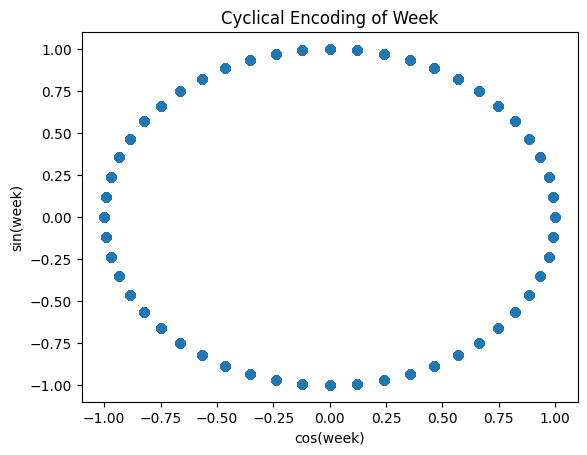

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_tree['Week_cos'], df_tree['Week_sin'])
plt.xlabel('cos(week)')
plt.ylabel('sin(week)')
plt.title('Cyclical Encoding of Week')
plt.show()

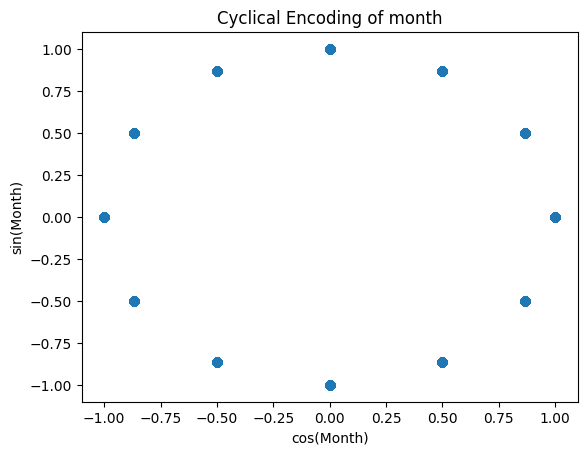

In [17]:
plt.figure()
plt.scatter(df_tree['Month_cos'], df_tree['Month_sin'])
plt.xlabel('cos(Month)')
plt.ylabel('sin(Month)')
plt.title('Cyclical Encoding of month')
plt.show()

In [18]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_tree[['Store', 'Year']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store', 'Year'])
)

df_tree= pd.concat([df_tree.drop(['Store', 'Year'], axis=1), encoded_df], axis=1)

# pre-processing MLR, SVM and NN - includes scaling and log transformation

all numerical features where scaled, weekly wales was log transformed then scaled to deal with skew

In [19]:
df_scaled['Weekly_Sales'] = np.log1p(df_scaled['Weekly_Sales'])

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# A dedicated scaler kept just for the target so we can inverse transform later
sales_scaler = StandardScaler()

df_scaled['Weekly_Sales_scaled']  = sales_scaler.fit_transform(df_scaled[['Weekly_Sales']])
df_scaled['Temperature_scaled']   = scaler.fit_transform(df_scaled[['Temperature']])
df_scaled['Fuel_Price_scaled']    = scaler.fit_transform(df_scaled[['Fuel_Price']])
df_scaled['CPI_scaled']           = scaler.fit_transform(df_scaled[['CPI']])
df_scaled['Unemployment_scaled']  = scaler.fit_transform(df_scaled[['Unemployment']])

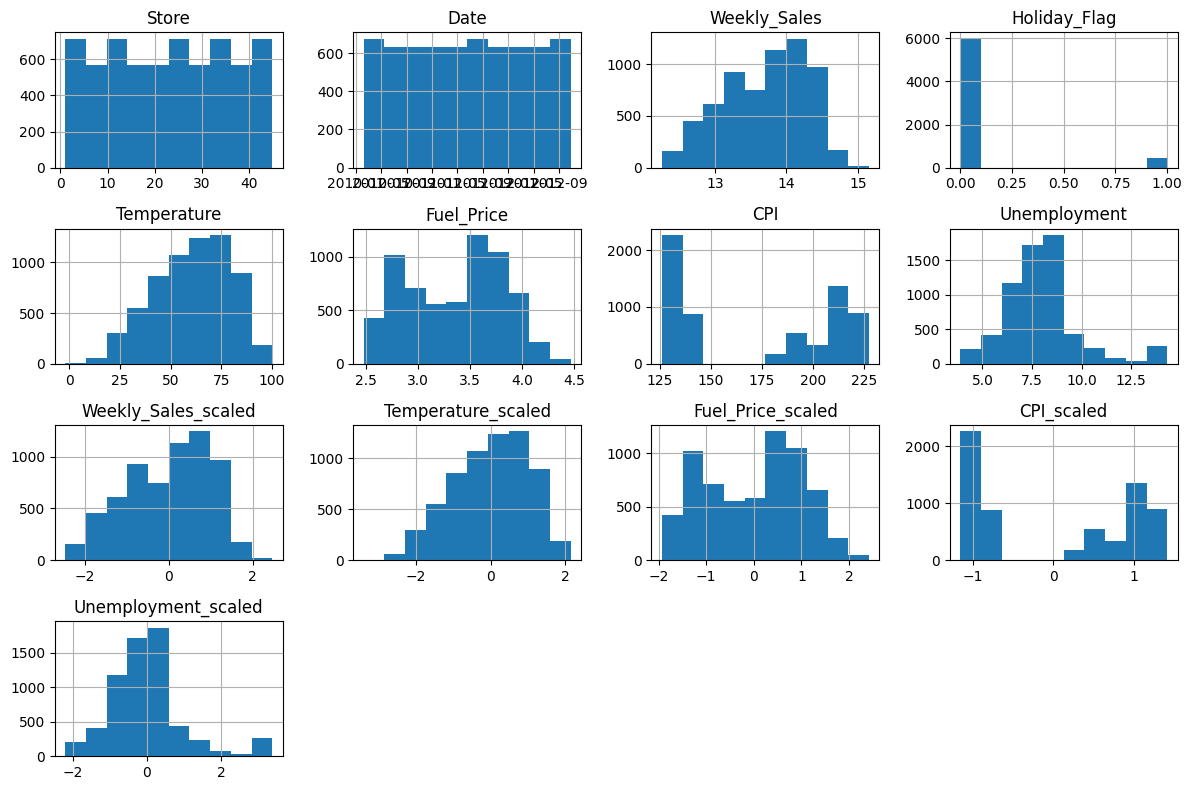

In [21]:
df_scaled.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

date time processing

In [22]:
df_scaled['Date'] = pd.to_datetime(df_scaled['Date'],dayfirst=True)

df_scaled['Year'] = df_scaled['Date'].dt.year
df_scaled['Month'] = df_scaled['Date'].dt.month
df_scaled['Week'] = df_scaled['Date'].dt.isocalendar().week

In [23]:
df_scaled['Month_sin'] = np.sin(2 * np.pi * df_scaled['Month'] / 12)
df_scaled['Month_cos'] = np.cos(2 * np.pi * df_scaled['Month'] / 12)

df_scaled['Week_sin'] = np.sin(2 * np.pi * df_scaled['Week'] / 52)
df_scaled['Week_cos'] = np.cos(2 * np.pi * df_scaled['Week'] / 52)

In [24]:
df_scaled.drop(['Date','Month','Week','Weekly_Sales','Temperature','Fuel_Price','Unemployment'], axis=1, inplace=True)

In [25]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                6435 non-null   int64  
 1   Holiday_Flag         6435 non-null   int64  
 2   CPI                  6435 non-null   float64
 3   Weekly_Sales_scaled  6435 non-null   float64
 4   Temperature_scaled   6435 non-null   float64
 5   Fuel_Price_scaled    6435 non-null   float64
 6   CPI_scaled           6435 non-null   float64
 7   Unemployment_scaled  6435 non-null   float64
 8   Year                 6435 non-null   int32  
 9   Month_sin            6435 non-null   float64
 10  Month_cos            6435 non-null   float64
 11  Week_sin             6435 non-null   Float64
 12  Week_cos             6435 non-null   Float64
dtypes: Float64(2), float64(8), int32(1), int64(2)
memory usage: 949.3 KB


In [26]:
df_scaled.head(1)

,Store,Holiday_Flag,CPI,Weekly_Sales_scaled,Temperature_scaled,Fuel_Price_scaled,CPI_scaled,Unemployment_scaled,Year,Month_sin,Month_cos,Week_sin,Week_cos
0,1,0,211.096358,1.037892,-0.995136,-1.7138,1.004175,0.056964,2010,0.866025,0.5,0.568065,0.822984


In [27]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_scaled[['Store', 'Year']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store', 'Year'])
)

df_scaled= pd.concat([df_scaled.drop(['Store', 'Year'], axis=1), encoded_df], axis=1)

#Scaled baselines

In [28]:
def inverse_transform(y_pred_scaled):
    y_pred_log = sales_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    return np.expm1(y_pred_log)

def evaluate_metrics(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R²   : {r2:.4f}\n")

def plot_predictions(name, y_test, y_pred):
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Weekly Sales ($)")
    plt.ylabel("Predicted Weekly Sales ($)")
    plt.title(name)
    plt.tight_layout()
    plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

split_idx = int(len(df_scaled) * 0.8)

X_scaled = df_scaled.drop(columns=['Weekly_Sales_scaled'])
y_scaled = df_scaled['Weekly_Sales_scaled']

X_scaled_train, X_scaled_test = X_scaled.iloc[:split_idx], X_scaled.iloc[split_idx:]
y_scaled_train, y_scaled_test = y_scaled.iloc[:split_idx], y_scaled.iloc[split_idx:]

# Compute actuals in dollars once
y_test_dollars = inverse_transform(y_scaled_test.values)

print(f"Train size: {len(X_scaled_train)} | Test size: {len(X_scaled_test)}")

Train size: 5148 | Test size: 1287


--- Multiple Linear Regression (Baseline) ---
  MAE  : 417,687.13
  RMSE : 505,588.32
  R²   : 0.1001



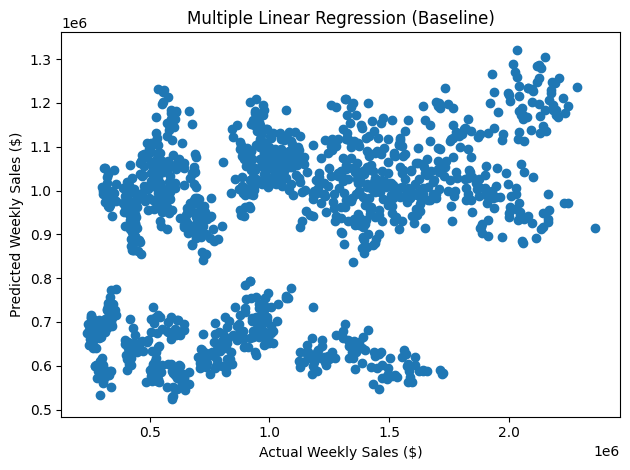

In [30]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_scaled_train, y_scaled_train)
y_pred_lr = inverse_transform(lr_model.predict(X_scaled_test))

evaluate_metrics("Multiple Linear Regression (Baseline)", y_test_dollars, y_pred_lr)
plot_predictions("Multiple Linear Regression (Baseline)", y_test_dollars, y_pred_lr)


--- SVR - RBF Kernel (Baseline) ---
  MAE  : 435,539.61
  RMSE : 548,701.29
  R²   : -0.0599



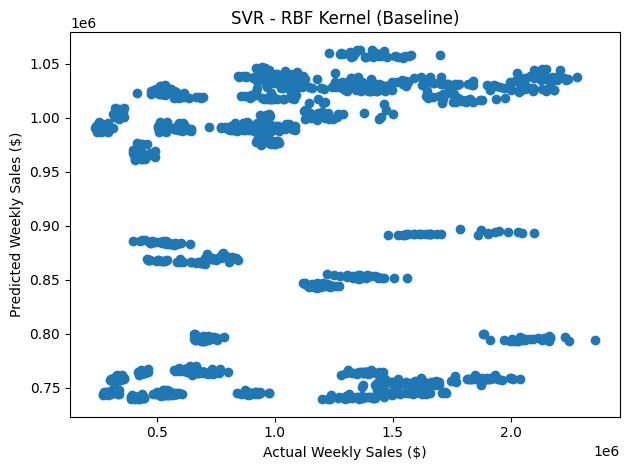

In [31]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_scaled_train, y_scaled_train)
y_pred_svr = inverse_transform(svr_model.predict(X_scaled_test))

evaluate_metrics("SVR - RBF Kernel (Baseline)", y_test_dollars, y_pred_svr)
plot_predictions("SVR - RBF Kernel (Baseline)", y_test_dollars, y_pred_svr)

--- Neural Network - MLP (Baseline) ---
  MAE  : 398,762.09
  RMSE : 496,006.12
  R²   : 0.1339



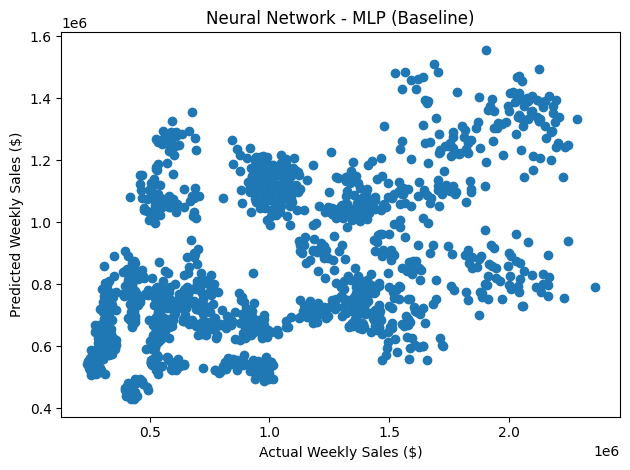

In [32]:
from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 2-layer baseline architecture
    activation='relu',
    max_iter=500,
    random_state=42
)
nn_model.fit(X_scaled_train, y_scaled_train)
y_pred_nn = inverse_transform(nn_model.predict(X_scaled_test)) b

evaluate_metrics("Neural Network - MLP (Baseline)", y_test_dollars, y_pred_nn)
plot_predictions("Neural Network - MLP (Baseline)", y_test_dollars, y_pred_nn)


In [33]:
!pip install Optuna

In [34]:
# import optuna
# from sklearn.neural_network import MLPRegressor
# from sklearn.model_selection import cross_val_score

# # Suppress optuna logging to keep output clean
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective(trial):
#     params = {
#         'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [
#             (64,), (128,), (64, 32), (128, 64), (128, 64, 32)
#         ]),
#         'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
#         'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
#         'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
#         'max_iter': 500,
#         'random_state': 42
#     }

#     model = MLPRegressor(**params)

#     # Negative RMSE as the objective (Optuna minimises by default)
#     scores = cross_val_score(
#         model, X_scaled_train, y_scaled_train,
#         cv=5, scoring='neg_root_mean_squared_error'
#     )
#     return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=20, show_progress_bar=True)

# print("Best params:", study.best_params)
# print(f"Best CV RMSE (scaled): {study.best_value:.4f}")

In [35]:
# best_nn = MLPRegressor(
#     **{k: v for k, v in study.best_params.items()},
#     max_iter=500,
#     random_state=42
# )
# best_nn.fit(X_scaled_train, y_scaled_train)
# y_pred_nn_tuned = inverse_transform(best_nn.predict(X_scaled_test))

# evaluate_metrics("Neural Network - MLP (Tuned)", y_test_dollars, y_pred_nn_tuned)
# plot_predictions("Neural Network - MLP (Tuned)", y_test_dollars, y_pred_nn_tuned)